In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

PROJECT_ROOT = Path.cwd().parent   
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.get_google_drive_data import load_csv_from_drive
from utils.google_drive_client import get_drive_client
from utils.utils import get_data_split
from utils.features import rate_table, rate_plot

In [2]:
service = get_drive_client()
df = load_csv_from_drive(service) 

In [3]:
X_train, X_test, y_train, y_test = get_data_split(df)
train_df = pd.concat([X_train, y_train], axis=1)

In [4]:
train_df.head()

,project id,name,url,category,subcategory,location,goal,pledged,funded percentage,backers,funded date,levels,reward levels,updates,comments,duration,target
40825,1914040019,Summit to Sea,http://www.kickstarter.com/projects/lahoffman/...,Art,Illustration,"Stevensville, Mt",8500.0,2034.0,0.239294,37,"Thu, 01 Mar 2012 06:59:00 -0000",10,"$10,$25,$35,$45,$95,$150,$200,$250,$325,$450",5,3,42.59,False
16576,783122916,Tamara Saari Dance,http://www.kickstarter.com/projects/1117453527...,Dance,Dance,"Lower East Side, NY",2000.0,2017.0,1.008555,36,"Thu, 01 Mar 2012 16:22:00 -0000",6,"$10,$25,$50,$100,$150,$250",6,0,31.60,True
5060,240036276,Four Clowns 2011 National Tour,http://www.kickstarter.com/projects/506558983/...,Theater,Theater,"Los Angeles, CA",5000.0,5210.0,1.042000,48,"Tue, 05 Jul 2011 03:59:00 -0000",7,"$10,$25,$50,$100,$200,$500,$1,000",3,0,40.99,True
47,2353033,&quot;Chased Resignation&quot;,http://www.kickstarter.com/projects/chasedresi...,Film & Video,Film &amp; Video,"Arcadia, CA",20000.0,0.0,0.000000,0,"Tue, 26 Jul 2011 04:00:00 -0000",3,"$20,$100,$1,000",0,0,63.23,False
6455,303755237,People Get Ready: The Parchman Hour is Coming!,http://www.kickstarter.com/projects/90005631/p...,Theater,Theater,"Jackson, MS",7000.0,7100.0,1.014286,104,"Wed, 25 May 2011 02:11:06 -0000",6,"$10,$30,$60,$100,$250,$500",36,11,30.00,True


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29375 entries, 40825 to 2247
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   project id         29375 non-null  int64  
 1   name               29375 non-null  object 
 2   url                29375 non-null  object 
 3   category           29375 non-null  object 
 4   subcategory        29375 non-null  object 
 5   location           28472 non-null  object 
 6   goal               29375 non-null  float64
 7   pledged            29375 non-null  float64
 8   funded percentage  29375 non-null  float64
 9   backers            29375 non-null  int64  
 10  funded date        29375 non-null  object 
 11  levels             29375 non-null  int64  
 12  reward levels      29335 non-null  object 
 13  updates            29375 non-null  int64  
 14  comments           29375 non-null  int64  
 15  duration           29375 non-null  float64
 16  target             29375

In [ ]:
info = pd.DataFrame({
    "dtype": X_train.dtypes.astype(str),
    "non-null": X_train.notna().sum(),
    "null": X_train.isna().sum(),
    "null %": (X_train.isna().mean() * 100).round(2),
    "unique": X_train.nunique(),
    "example": X_train.iloc[0].astype(str).str.slice(0, 40),
})
info

,dtype,non-null,null,null %,unique,example
project id,int64,29375,0,0.00,29321,1914040019
name,object,29375,0,0.00,29288,Summit to Sea
url,object,29375,0,0.00,29321,http://www.kickstarter.com/projects/laho
category,object,29375,0,0.00,14,Art
subcategory,object,29375,0,0.00,51,Illustration
location,object,28472,903,3.07,3682,"Stevensville, Mt"
goal,float64,29375,0,0.00,1340,8500.0
pledged,float64,29375,0,0.00,8740,2034.0
funded percentage,float64,29375,0,0.00,15153,0.239294118
backers,int64,29375,0,0.00,795,37


In [ ]:
train_df.describe()

,project id,goal,pledged,funded percentage,backers,levels,updates,comments,duration
count,2.937500e+04,2.937500e+04,2.937500e+04,29375.000000,29375.000000,29375.000000,29375.000000,29375.000000,29375.000000
mean,1.077376e+09,9.454898e+03,5.292068e+03,1.556393,73.304102,7.948357,4.308289,8.625260,40.174240
std,6.217019e+08,3.986794e+04,6.906815e+04,60.919587,812.774143,4.133787,6.550769,184.864453,17.775351
min,3.940900e+04,1.000000e-02,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,5.394866e+08,1.600000e+03,2.200000e+02,0.051000,5.000000,5.000000,0.000000,0.000000,30.000000
50%,1.071316e+09,4.000000e+03,1.447000e+03,1.005200,24.000000,7.000000,2.000000,1.000000,32.040000
75%,1.620217e+09,8.500000e+03,4.354500e+03,1.130879,61.000000,10.000000,6.000000,3.000000,48.940000
max,2.147460e+09,3.500000e+06,1.026684e+07,10000.000000,87142.000000,74.000000,142.000000,19311.000000,91.960000


# Exploring the Goal Feature
We can see the dataset has a big range. In Figure 1 we can see most goals seem to be concentrated at relatively small dollar amounts. Figure 2 makes this even more clear as we can see the distrubution is centered from 3000-10000 dollars goals. Through these figures we can clearly see we we have a long-tailed, right-skewed distribution.

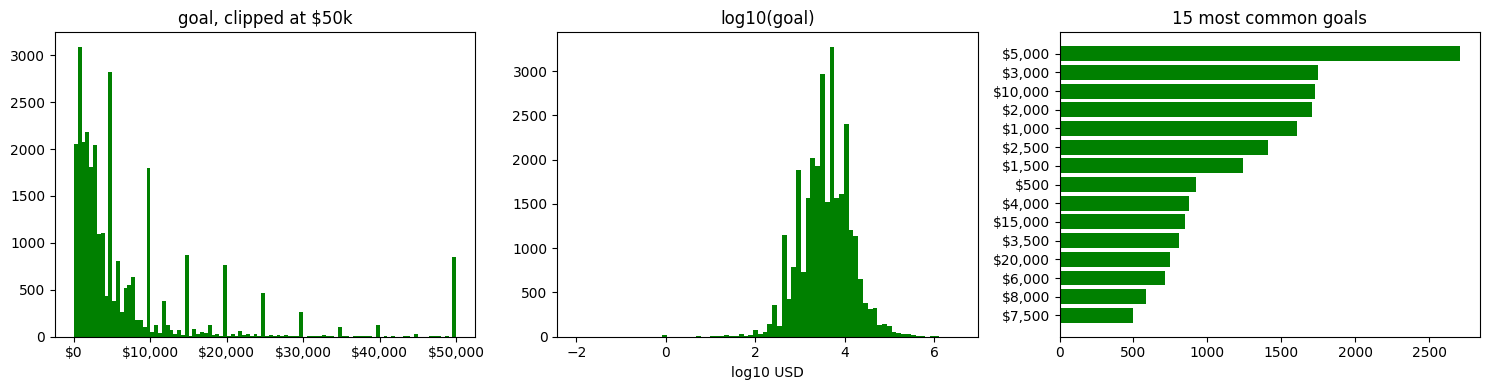

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(X_train["goal"].clip(upper=50_000), bins=100, color='green')
axes[0].set_title("goal, clipped at $50k"); axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].hist(np.log10(X_train["goal"]), bins=80, color='green')
axes[1].set_title("log10(goal)"); axes[1].set_xlabel("log10 USD")
top = X_train["goal"].value_counts().head(15)
axes[2].barh([f"${int(v):,}" for v in top.index][::-1], top.values[::-1], color='green')
axes[2].set_title("15 most common goals")
plt.tight_layout()

# Success rate by Goal
As we can see success rate is higher for lower goal amounts, however it get progressively lower as the goal amount increases.

,n,rate,ci_lo,ci_hi,vs_base
goal,,,,,
<$500,2058,0.719,0.699,0.738,0.172
$500–1k,3089,0.674,0.657,0.690,0.126
$1–2k,4256,0.661,0.647,0.675,0.114
$2–3k,3858,0.622,0.606,0.637,0.074
$3–5k,5449,0.548,0.534,0.561,0.000
$5–7.5k,2521,0.525,0.505,0.544,-0.023
$7.5–10k,2909,0.460,0.442,0.478,-0.088
$10–15k,1802,0.415,0.393,0.438,-0.132
$15–25k,1796,0.325,0.303,0.347,-0.223


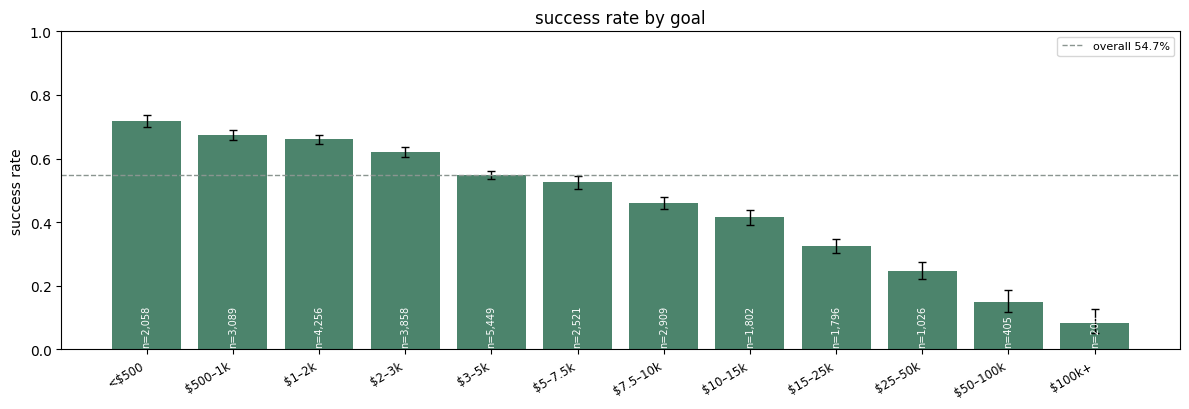

In [ ]:
bins = [0, 500, 1000, 2000, 3000, 5000, 7500, 10000, 15000, 25000, 50000, 100000, 1e9]
labels = ["<$500", "$500–1k", "$1–2k", "$2–3k", "$3–5k", "$5–7.5k", "$7.5–10k", "$10–15k", "$15–25k", "$25–50k", "$50–100k", "$100k+"]
g_goal = rate_table(train_df, pd.cut(train_df["goal"], bins, labels=labels))
fig, ax = plt.subplots(figsize=(12, 4.2))
rate_plot(ax, g_goal, "success rate by goal", rotate=30)
plt.tight_layout()
g_goal[["n", "rate", "ci_lo", "ci_hi", "vs_base"]].round(3)

There seems to be a small correlation between success rate and duration of the campaign. With the campaign being more likely to be successful if it lasted less. We can also see that we have two commonly chosen durations, though these might just be a preference for those particular numbers rather than any additional information.

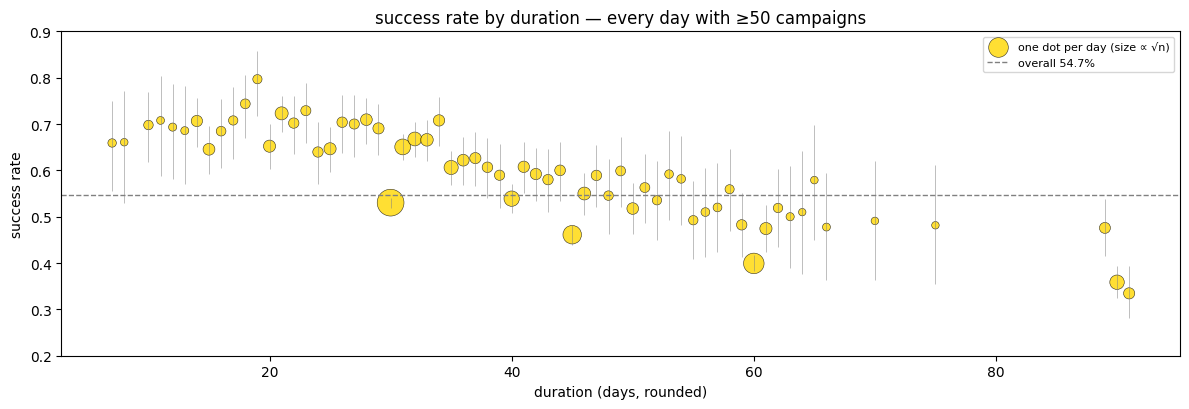

In [18]:
by_day = rate_table(train_df, train_df["duration"].round().astype(int))

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.scatter(by_day.index, by_day["rate"], s=np.sqrt(by_day["n"]) * 4, color='gold', alpha=0.8,
           edgecolor="k", lw=0.4, label="one dot per day (size ∝ √n)")
ax.errorbar(by_day.index, by_day["rate"], yerr=[by_day["rate"] - by_day["ci_lo"], by_day["ci_hi"] - by_day["rate"]],
            fmt="none", ecolor='grey', lw=0.6, alpha=0.6)
ax.axhline(by_day.attrs["base"], color='grey', ls="--", lw=1, label=f"overall {by_day.attrs['base']:.1%}")

ax.set_xlabel("duration (days, rounded)"); ax.set_ylabel("success rate"); ax.set_ylim(0.2, 0.9)
ax.set_title("success rate by duration — every day with ≥50 campaigns"); ax.legend(fontsize=8)
plt.tight_layout()

# Success by Category
Overall there is a big difference between the success of different categories, however this might also be because there is a small overlap between the msot popular categories and the most succesful.

the 2 largest categories cover 53.0% of the training set; the 6 smallest cover 12.3%


,n,share,cumulative share,n subcategories,median goal
category,,,,,
Film &amp; Video,8555,0.291,0.291,6,5000.0
Music,7022,0.239,0.530,11,3000.0
Publishing,2866,0.098,0.628,8,3500.0
Art,2602,0.089,0.716,9,2700.0
Theater,1608,0.055,0.771,1,2500.0
Design,1084,0.037,0.808,4,6000.0
Games,1054,0.036,0.844,4,5000.0
Photography,979,0.033,0.877,1,3000.0
Food,918,0.031,0.909,1,7500.0


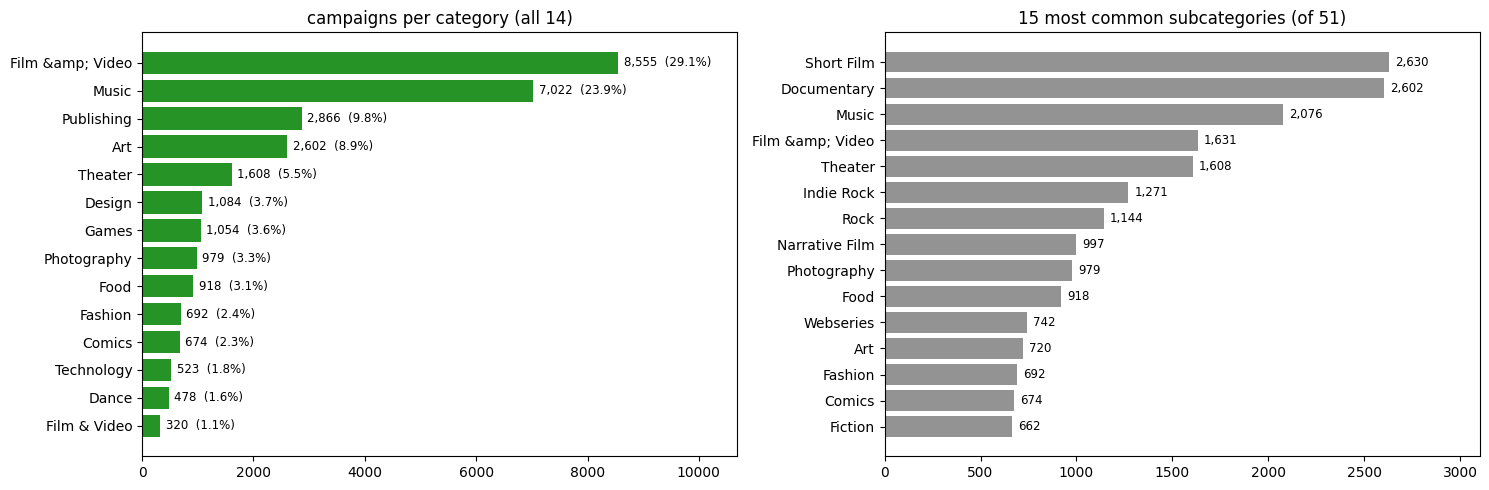

In [20]:
cat_n = train_df["category"].value_counts()
sub_n = train_df["subcategory"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
ax.barh(cat_n.index[::-1], cat_n.values[::-1], color='green', alpha=0.85)
for i, v in enumerate(cat_n.values[::-1]):
    ax.text(v + cat_n.max() * 0.012, i, f"{v:,}  ({v/len(train_df):.1%})", va="center", fontsize=8.5)
ax.set_xlim(0, cat_n.max() * 1.25)
ax.set_title(f"campaigns per category (all {len(cat_n)})")

ax = axes[1]
topk = sub_n.head(15)
ax.barh(topk.index[::-1], topk.values[::-1], color='grey', alpha=0.85)
for i, v in enumerate(topk.values[::-1]):
    ax.text(v + topk.max() * 0.012, i, f"{v:,}", va="center", fontsize=8.5)
ax.set_xlim(0, topk.max() * 1.18)
ax.set_title(f"15 most common subcategories (of {len(sub_n)})")
plt.tight_layout()

summary = pd.DataFrame({"n": cat_n, "share": cat_n / len(train_df)})
summary["cumulative share"] = summary["share"].cumsum()
summary["n subcategories"] = train_df.groupby("category")["subcategory"].nunique()
summary["median goal"] = train_df.groupby("category")["goal"].median()
print(f"the 2 largest categories cover {summary['share'].head(2).sum():.1%} of the training set; "
      f"the 6 smallest cover {summary['share'].tail(6).sum():.1%}")
summary.round(3)

,n,rate,vs_base,median goal
category,,,,
Dance,478,0.759,0.212,2500.0
Theater,1608,0.705,0.158,2500.0
Music,7022,0.674,0.126,3000.0
Art,2602,0.578,0.031,2700.0
Film & Video,320,0.550,0.003,5000.0
Comics,674,0.539,-0.009,3000.0
Food,918,0.509,-0.039,7500.0
Film &amp; Video,8555,0.507,-0.040,5000.0
Design,1084,0.465,-0.082,6000.0


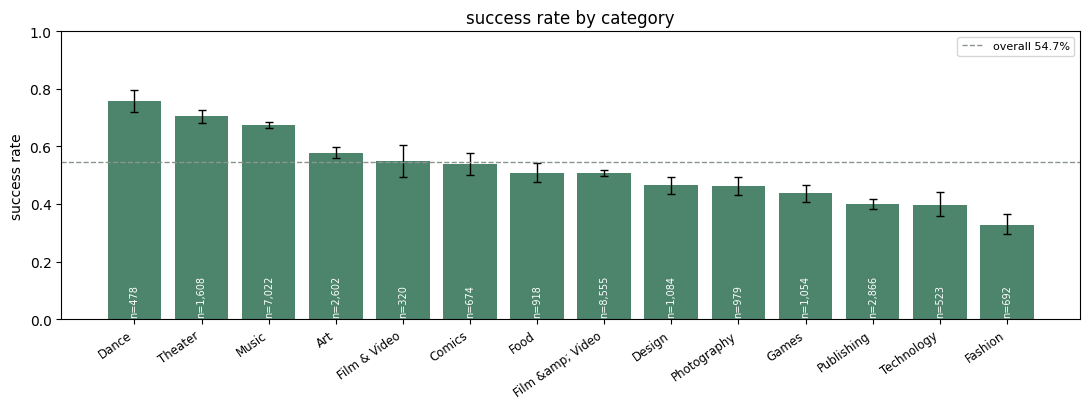

In [6]:
g_cat = rate_table(train_df, "category").sort_values("rate", ascending=False)
g_cat["median goal"] = train_df.groupby("category")["goal"].median()
fig, ax = plt.subplots(figsize=(11, 4.2))
rate_plot(ax, g_cat, "success rate by category", rotate=35)
plt.tight_layout()
g_cat[["n", "rate", "vs_base", "median goal"]].round(3)

,n,rate,category,median goal
subcategory,,,,
Dance,478,0.759,Dance,2500.0
Country &amp; Folk,524,0.758,Music,3300.0
Indie Rock,1271,0.744,Music,2500.0
Classical Music,302,0.732,Music,3000.0
Country & Folk,160,0.731,Music,3000.0
Jazz,299,0.709,Music,4000.0
Theater,1608,0.705,Theater,2500.0
Rock,1144,0.676,Music,2500.0
Public Art,339,0.673,Art,3000.0


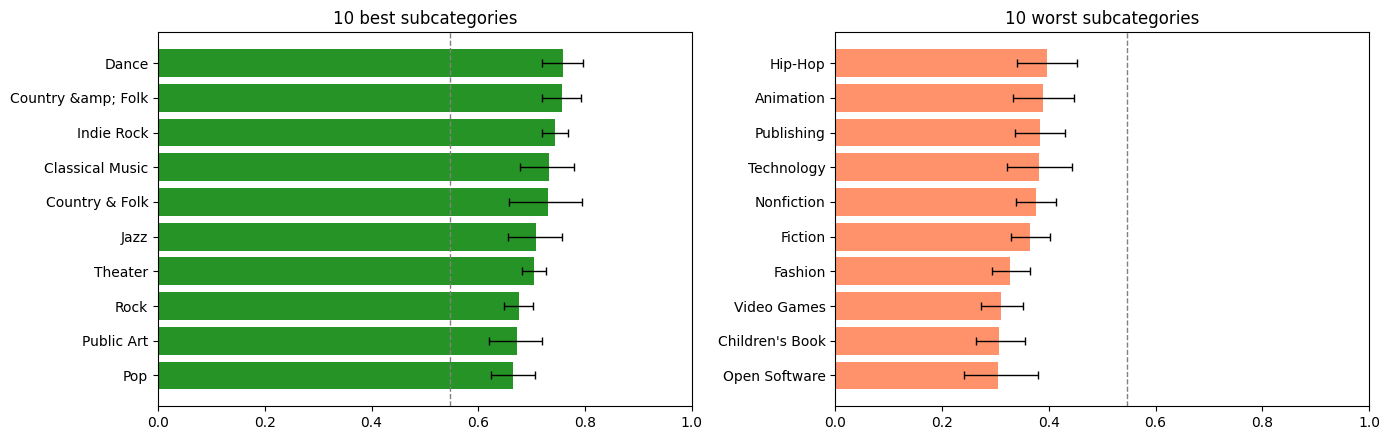

In [8]:
g_sub = rate_table(train_df, "subcategory", min_n=150)
g_sub["category"] = train_df.groupby("subcategory")["category"].agg(lambda s: s.mode()[0])
g_sub["median goal"] = train_df.groupby("subcategory")["goal"].median()
top, bot = g_sub.nlargest(10, "rate"), g_sub.nsmallest(10, "rate")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, g, t, col in [(axes[0], top.iloc[::-1], "10 best subcategories", 'green'), (axes[1], bot, "10 worst subcategories", 'coral')]:
    ax.barh(g.index, g["rate"], color=col, alpha=0.85)
    ax.errorbar(g["rate"], range(len(g)), xerr=[g["rate"] - g["ci_lo"], g["ci_hi"] - g["rate"]], fmt="none", ecolor="k", capsize=3, lw=1)
    ax.axvline(train_df["target"].mean(), color='grey', ls="--", lw=1); ax.set_xlim(0, 1); ax.set_title(t)
plt.tight_layout()
pd.concat([top, bot])[["n", "rate", "category", "median goal"]].round(3)

# Reward Tiers
There is a small correlation between geometric step, average multiplier between one tier and the next, and success, whether the reward tiers actually contribute to overall success would be difficult to determine since we would probably have to observe behavior over time, and how reaching a reward, or being close to one affect the donations received.

,n,rate,ci_lo,ci_hi,vs_base
tier_step,,,,,
"(0.999, 1.699]",3583,0.679,0.664,0.694,0.132
"(1.699, 1.919]",3700,0.633,0.617,0.648,0.086
"(1.919, 2.115]",3846,0.602,0.586,0.617,0.055
"(2.115, 2.187]",3566,0.599,0.583,0.615,0.052
"(2.187, 2.43]",3634,0.534,0.518,0.551,-0.013
"(2.43, 2.683]",3225,0.510,0.493,0.527,-0.038
"(2.683, 3.162]",3550,0.464,0.448,0.481,-0.083
"(3.162, 1000.0]",3527,0.395,0.379,0.411,-0.152


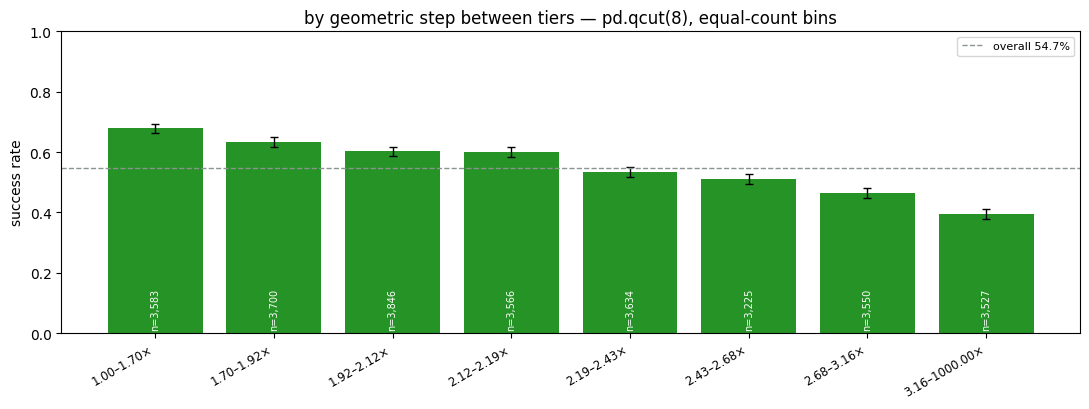

In [17]:
ts = rate_table(train_df, pd.qcut(train_df["tier_step"], 8, duplicates="drop"))
fig, ax = plt.subplots(figsize=(11, 4.2))
rate_plot(ax, ts, "by geometric step between tiers — pd.qcut(8) ", color='green',
          labels=[f"{iv.left:.2f}–{iv.right:.2f}×" for iv in ts.index], rotate=30)
plt.tight_layout()
ts[["n", "rate", "ci_lo", "ci_hi", "vs_base"]].round(3)

# Success rate by state

                  n   rate  vs_base
has_location                       
blank           903  0.481   -0.067
given         28472  0.549    0.002


,n,rate,vs_base
state,,,
FL,956,0.359,-0.189
NV,238,0.374,-0.173
GA,692,0.418,-0.130
NJ,383,0.436,-0.111
AZ,393,0.445,-0.102
OR,810,0.594,0.046
IL,1224,0.603,0.056
LA,309,0.621,0.074
MA,867,0.645,0.097


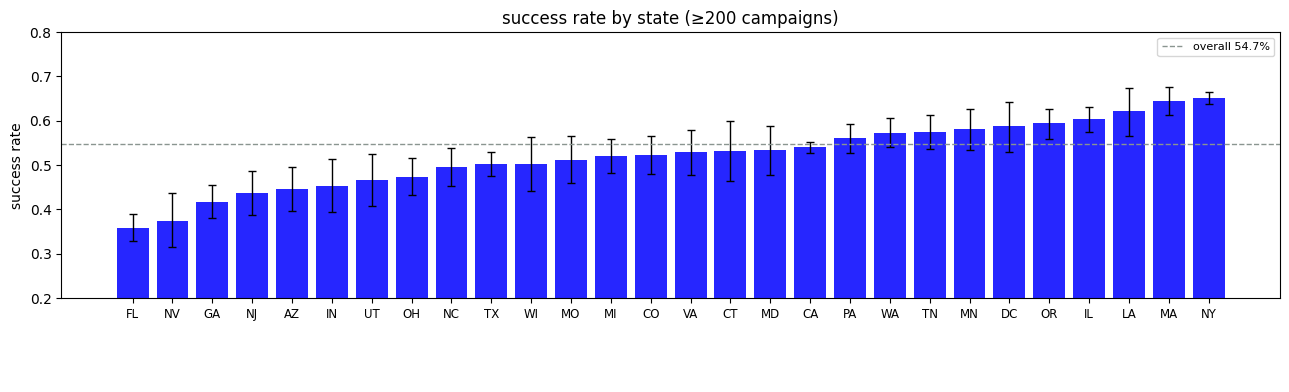

In [12]:
loc = train_df["location"].astype(str)
train_df["state"] = loc.str.extract(r",\s*([A-Z]{2})\s*$")[0]
train_df["has_location"] = train_df["location"].notna().astype(int)
print(rate_table(train_df, "has_location").rename(index={0: "blank", 1: "given"})[["n", "rate", "vs_base"]].round(3))
g_st = rate_table(train_df, "state", min_n=200).sort_values("rate")
fig, ax = plt.subplots(figsize=(13, 4.2))
rate_plot(ax, g_st, "success rate by state (≥200 campaigns)", color='blue', rotate=0)
ax.set_ylim(0.2, 0.8)
plt.tight_layout()
pd.concat([g_st.head(5), g_st.tail(5)])[["n", "rate", "vs_base"]].round(3)

# Examing cross-tabulated heatmaps of category, success rate, target, and duration

As expected, most categories do better with smaller goals; we can also see the earlier chart on duration against success rate supported here, however we can also see the impact on the success rate also depends on the goal for the crowdfounding, with it mattering more for bigger goals than smaller ones when comparing by pct increased or decreased.

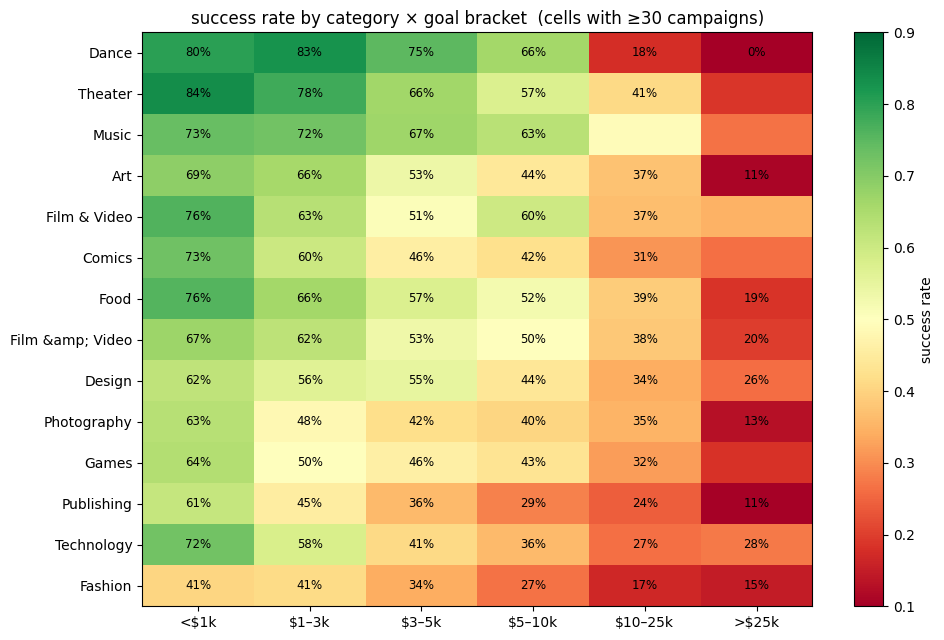

In [13]:
gb = pd.cut(train_df["goal"], [0, 1000, 3000, 5000, 10000, 25000, 1e9], labels=["<$1k", "$1–3k", "$3–5k", "$5–10k", "$10–25k", ">$25k"])
ct = pd.crosstab(train_df["category"], gb, values=train_df["target"], aggfunc="mean")
cn = pd.crosstab(train_df["category"], gb)
ct = ct.loc[g_cat.index]
fig, ax = plt.subplots(figsize=(10, 6.5))
im = ax.imshow(ct.values, cmap="RdYlGn", vmin=0.1, vmax=0.9, aspect="auto")
ax.set_xticks(range(ct.shape[1])); ax.set_xticklabels(ct.columns)
ax.set_yticks(range(ct.shape[0])); ax.set_yticklabels(ct.index)
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        if cn.iloc[i, j] >= 30:
            ax.text(j, i, f"{ct.iloc[i, j]:.0%}", ha="center", va="center", fontsize=8.5)
plt.colorbar(im, ax=ax, label="success rate"); ax.grid(False)
ax.set_title("success rate by category × goal bracket  (cells with ≥30 campaigns)")
plt.tight_layout()

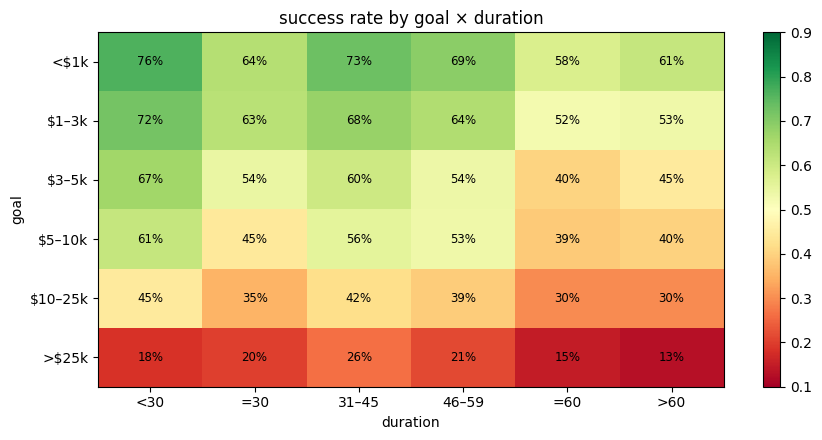

In [15]:
db = pd.cut(train_df["duration"], [0, 29.5, 30.5, 45, 59.5, 60.5, 100], labels=["<30", "=30", "31–45", "46–59", "=60", ">60"])
ct2 = pd.crosstab(gb, db, values=train_df["target"], aggfunc="mean")
cn2 = pd.crosstab(gb, db)
fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(ct2.values, cmap="RdYlGn", vmin=0.1, vmax=0.9, aspect="auto")
ax.set_xticks(range(ct2.shape[1])); ax.set_xticklabels(ct2.columns); ax.set_xlabel("duration")
ax.set_yticks(range(ct2.shape[0])); ax.set_yticklabels(ct2.index); ax.set_ylabel("goal")
for i in range(ct2.shape[0]):
    for j in range(ct2.shape[1]):
        if cn2.iloc[i, j] >= 30:
            ax.text(j, i, f"{ct2.iloc[i, j]:.0%}", ha="center", va="center", fontsize=8.5)
plt.colorbar(im, ax=ax); ax.grid(False); ax.set_title("success rate by goal × duration")
plt.tight_layout()

# Distribution of the target Variable 

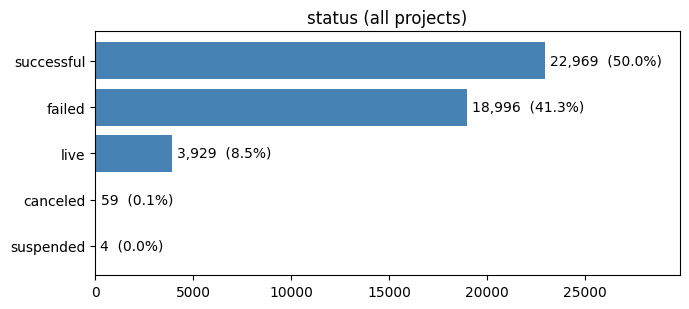

In [ ]:
order = ["successful", "failed", "live", "canceled", "suspended"]
st = df["status"].value_counts().reindex(order, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(st.index[::-1], st.values[::-1], color="steelblue")
for i, v in enumerate(st.values[::-1]):
    ax.text(v + st.max() * 0.01, i, f"{v:,}  ({v/len(df):.1%})", va="center")
ax.set_xlim(0, st.max() * 1.3)
ax.set_title("status (all projects)")
plt.tight_layout()